In [1]:
import pandas as pd
import numpy as np

In [2]:
df = pd.read_csv('/kaggle/input/nndataset/train_nn.csv')

In [3]:
df.drop('target_reg',axis =1,inplace = True)

In [4]:
df = df.iloc[: ,1:]

In [5]:
df.describe()

,F_1,F_2,F_3,F_4,F_5,F_6,F_7,F_8,F_9,F_10,...,F_12,F_13,F_14,F_15,F_16,F_17,F_18,F_19,F_20,target_cls
count,16000.000000,16000.000000,16000.000000,16000.000000,16000.000000,16000.000000,16000.000000,16000.000000,16000.000000,16000.000000,...,16000.000000,16000.000000,16000.000000,16000.000000,16000.000000,16000.000000,16000.000000,16000.000000,16000.000000,16000.000000
mean,4.024687,7.042125,5.121250,5.377063,3.506250,6.897625,7.494375,4.635063,5.180125,8.287437,...,7.929437,3.045437,8.334500,3.690937,7.802500,16.080725,6.475156,4.718224,49.390275,13.464438
std,1.911820,3.303583,2.016384,2.266237,2.190037,2.030739,2.325872,2.710967,2.391477,2.491426,...,2.083112,2.332158,1.543295,2.566092,1.616913,6.331444,2.989346,2.213400,27.644889,7.517107
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.900000,1.000000
25%,3.000000,5.000000,4.000000,4.000000,2.000000,6.000000,6.000000,3.000000,4.000000,7.000000,...,7.000000,1.000000,8.000000,2.000000,7.000000,12.560000,5.000000,3.350000,32.100000,7.000000
50%,4.000000,7.000000,5.000000,6.000000,3.000000,7.000000,7.000000,4.000000,5.000000,8.000000,...,8.000000,3.000000,8.000000,3.000000,8.000000,15.700000,6.250000,4.690000,43.800000,13.000000
75%,5.000000,9.000000,6.000000,7.000000,5.000000,8.000000,9.000000,6.000000,7.000000,10.000000,...,9.000000,4.000000,9.000000,5.000000,8.000000,18.840000,8.750000,6.030000,63.300000,20.000000
max,15.000000,15.000000,15.000000,15.000000,15.000000,15.000000,15.000000,15.000000,15.000000,15.000000,...,15.000000,15.000000,15.000000,15.000000,15.000000,47.100000,18.750000,10.050000,156.300000,26.000000


In [6]:
df.shape

(16000, 21)

In [7]:
testdf = df.sample(frac = 0.4,random_state=42)
df.drop(testdf.index,inplace = True)

In [8]:
xs = df.drop(['target_cls'],axis = 1)
reg_targets = df.target_cls
txs = testdf.drop(['target_cls'],axis = 1)
target = testdf.target_cls


In [9]:
metric = pd.DataFrame({'label' : xs.columns,
              'mean' : np.mean(xs,axis =0),
              'std' : np.std(xs,axis = 0)})

In [10]:
for col in xs.columns:
  xs[col] = (xs[col] - np.mean(xs[col]))/np.std(xs[col])

In [11]:
xs.describe()

,F_1,F_2,F_3,F_4,F_5,F_6,F_7,F_8,F_9,F_10,F_11,F_12,F_13,F_14,F_15,F_16,F_17,F_18,F_19,F_20
count,9.600000e+03,9.600000e+03,9.600000e+03,9.600000e+03,9.600000e+03,9.600000e+03,9.600000e+03,9.600000e+03,9.600000e+03,9.600000e+03,9.600000e+03,9.600000e+03,9.600000e+03,9.600000e+03,9.600000e+03,9.600000e+03,9.600000e+03,9.600000e+03,9.600000e+03,9.600000e+03
mean,2.072416e-17,6.698346e-17,1.872576e-16,3.016106e-17,-1.065814e-16,-1.724546e-16,-1.635729e-16,7.012909e-17,-1.443290e-17,-1.409983e-16,-1.391480e-16,1.432188e-16,6.661338e-17,-3.400983e-16,-7.568020e-17,1.485848e-16,-4.520458e-16,8.604228e-17,7.512509e-17,6.346775e-17
std,1.000052e+00,1.000052e+00,1.000052e+00,1.000052e+00,1.000052e+00,1.000052e+00,1.000052e+00,1.000052e+00,1.000052e+00,1.000052e+00,1.000052e+00,1.000052e+00,1.000052e+00,1.000052e+00,1.000052e+00,1.000052e+00,1.000052e+00,1.000052e+00,1.000052e+00,1.000052e+00
min,-2.086409e+00,-2.118560e+00,-2.515389e+00,-2.354843e+00,-1.603186e+00,-3.383946e+00,-3.198600e+00,-1.700566e+00,-2.170449e+00,-3.299742e+00,-2.447893e+00,-3.303109e+00,-1.299722e+00,-5.433712e+00,-1.434006e+00,-4.227910e+00,-2.515389e+00,-2.170449e+00,-2.118560e+00,-1.744321e+00
25%,-5.224167e-01,-6.101959e-01,-5.425350e-01,-5.979756e-01,-6.800740e-01,-4.380488e-01,-6.355908e-01,-5.989601e-01,-5.034441e-01,-5.123843e-01,-5.528112e-01,-4.476952e-01,-8.668574e-01,-2.088581e-01,-6.548535e-01,-5.070908e-01,-5.425350e-01,-5.034441e-01,-6.101959e-01,-6.317176e-01
50%,-1.086105e-03,-6.850485e-03,-4.932136e-02,2.804583e-01,-2.185180e-01,5.293409e-02,-2.084225e-01,-2.317581e-01,-8.669292e-02,-1.141904e-01,-1.737948e-01,2.820713e-02,-1.127253e-03,-2.088581e-01,-2.652772e-01,1.130457e-01,-4.932136e-02,-8.669292e-02,-6.850485e-03,-2.104405e-01
75%,5.202445e-01,5.964950e-01,4.438923e-01,7.196753e-01,7.045942e-01,5.439170e-01,6.459140e-01,5.026461e-01,7.468094e-01,6.821974e-01,5.842380e-01,5.041095e-01,4.317378e-01,4.442486e-01,5.138756e-01,7.331823e-01,4.438923e-01,7.468094e-01,5.964950e-01,5.024899e-01
max,5.733551e+00,2.406531e+00,4.882815e+00,4.233411e+00,5.320155e+00,3.980797e+00,3.208924e+00,3.807465e+00,4.080819e+00,2.673167e+00,3.237353e+00,3.359524e+00,5.193253e+00,3.709782e+00,4.409639e+00,4.454001e+00,4.882815e+00,4.080819e+00,2.406531e+00,3.851103e+00


In [12]:
class Neuron:
    __slots__ = ['data', 'grad', 'children', '_backward']
    def __init__(self, data,children = (),_backward = lambda : None):
        self.data = data
        self.grad = 0.0
        self.children = children
        self._backward = lambda : None

    def __mul__(self,other):
        other = other if isinstance(other,Neuron) else Neuron(other)
        out = Neuron(self.data*other.data)
        out.children = (self,other)
        def _backward():
            self.grad += other.data*out.grad
            other.grad += self.data*out.grad
        out._backward = _backward
        return out

    def __add__(self,other):
        other = other if isinstance(other,Neuron) else Neuron(other)
        out = Neuron(self.data + other.data)
        out.children = (self,other)
        def _backward():
            self.grad += 1.0*out.grad
            other.grad += 1.0*out.grad
        out._backward = _backward
        return out

    def __sub__(self,other):
        other = other if isinstance(other,Neuron) else Neuron(other)
        out = Neuron(self.data - other.data)
        out.children = (self,other)
        def _backward():
            self.grad += 1.0*out.grad
            other.grad -= 1.0*out.grad
        out._backward = _backward
        return out

    def relu(self):
        out = Neuron(self.data) if self.data > 0 else Neuron(0)
        out.children = (self,)
        def _backward():
            self.grad += out.grad*1 if self.data > 0 else 0
        out._backward = _backward
        return out

    def __truediv__(self, other):
        return self * other**-1

    def __rtruediv__(self, other):
        return other * self**-1

    def __pow__(self,other : float):
        # other = other if isinstance(other,Neuron) else Neuron(other) we are not doing this cuz
        # if other.data < 0 we might have to face a problem of get undefined
        # to avoid that I am considering other over here as an int variable only
        def _backward():
            self.grad += (other*(self.data**(other - 1)))*out.grad
        out = Neuron(self.data**other)
        out.children = (self,)
        out._backward = _backward
        return out

    def __radd__(self,other):
        other = other if isinstance(other,Neuron) else Neuron(other)
        out = Neuron(self.data + other.data)
        out.children = (self,other)
        def _backward():
            self.grad += 1.0*out.grad
            other.grad += 1.0*out.grad
        out._backward = _backward
        return out

    def __rsub__(self,other):
        other = other if isinstance(other,Neuron) else Neuron(other)
        out = Neuron(self.data - other.data)
        out.children = (self,other)
        def _backward():
            self.grad += 1.0*out.grad
            other.grad -= 1.0*out.grad
        out._backward = _backward
        return out

    def __rmul__(self,other):
        other = other if isinstance(other,Neuron) else Neuron(other)
        out = Neuron(self.data * other.data)
        out.children = (self,other)
        def _backward():
            self.grad += other.data*out.grad
            other.grad += self.data*out.grad
        out._backward = _backward
        return out



    def __rpow__(self,other : float):
        out = Neuron(self.data**other)
        def _backward():
            self.grad += (other*(self.data**(other - 1)))*out.grad
        out.children = (self,other)
        out._backward = _backward
        return out

    def __neg__(self):
        out = Neuron(-self.data)
        out.children = (self,)
        def _backward():
            self.grad += -1.0*out.grad
        out._backward = _backward
        return out

    def tanh(self):
        out = Neuron((np.exp(2*self.data) - 1)/(np.exp(2*self.data) + 1))
        out.children = (self,)
        def _backward():
            self.grad += out.grad*(1 - out.data ** 2)
        out._backward = _backward
        return out

    def log(self):
        out = Neuron(np.log(np.maximum(self.data, 1e-12)), (self,))
        def _backward():
            self.grad += (1.0 / self.data) * out.grad
        out._backward = _backward
        return out

    def exp(self):
        out = Neuron(np.exp(self.data), (self,))
        def _backward():
            self.grad += out.data * out.grad
        out._backward = _backward
        return out

    def __repr__(self):
        return f"Neuron({self.data} | grad {self.grad})"

    
    def backward(self):
        
        topo = []
        visited = set()
        
        stack = [(self, 0)] 
        
        while stack:
            node, state = stack.pop()
            if state == 0:
                if node in visited:
                    continue
                visited.add(node)
                
                stack.append((node, 1))
                
                for child in node.children:
                    if isinstance(child, Neuron) and child not in visited:
                        stack.append((child, 0))
            else:
                topo.append(node)

        
        self.grad = 1.0
        for node in reversed(topo):
            node._backward()


class Module:

    def zero_grad(self):
        for p in self.parameters():
            p.grad = 0

    def parameters(self):
        return []

class Node(Module):
    __slots__ = ['w', 'b', 'nin', 'nonlin']
    def __init__(self, nin, nonlin=True):
        # intializing the default mode be a relu unit with He activation
        self.w = [Neuron(np.random.normal(0,np.sqrt(2/nin))) for _ in range(nin)]
        self.b = Neuron(0)
        self.nin = nin
        self.nonlin = nonlin

    def __call__(self, x):
        act = sum((wi*xi for wi,xi in zip(self.w, x)), self.b)
        return act.relu() if self.nonlin else act

    def parameters(self):
        return self.w + [self.b]

    def __repr__(self):
        return f"{'ReLU' if self.nonlin else 'Linear'}Neuron({len(self.w)})"

class Layer(Module):

    def __init__(self, nin, nout,weight_intializer = 'He' ,nonlin = False ,**kwargs):
        self.neurons = [Node(nin, nonlin) for _ in range(nout)]
        def He():
            for neuron in self.neurons:
                neuron.w = [Neuron(np.random.normal(0, np.sqrt(2 / neuron.nin))) for _ in range(neuron.nin)]
        def Xavier():
            for neuron in self.neurons:
                neuron.w = [Neuron(np.random.normal(0, np.sqrt(2 / (neuron.nin + nout)))) for _ in range(neuron.nin)]
        if weight_intializer == 'He':
            He()
        elif weight_intializer == 'Xavier':
            Xavier()
        else:
            raise ValueError(f'Unknown weight initialization : {weight_intializer}')

    def __call__(self, x):
        out = [n(x) for n in self.neurons]
        return out[0] if len(out) == 1 else out

    def parameters(self):
        return [p for n in self.neurons for p in n.parameters()]

    def __repr__(self):
        return f"Layer of [{', '.join(str(n) for n in self.neurons)}]"
class Softmax(Module):
    def __init__(self, nfeatures):
        self.nfeatures = nfeatures

    def __call__(self, x):
        exp_x = [a.exp() for a in x]
        exp_sum = sum(exp_x)
        return [expi / exp_sum for expi in exp_x]

def sparse_categorical_crossentropy(logits, target):
    max_val = max(l.data for l in logits)
    shifted_logits = [l - max_val for l in logits]
    logitsexp = [logit.exp() for logit in logits]
    total = sum(logitsexp)
    probs = [le / total for le in logitsexp]
    return probs[int(target)].log() * Neuron(-1.0)


class MLP(Module):

    def __init__(self, Layers):
        self.x = None
        self.y = None
        self.layers = Layers
        self.params = self.parameters()
        self.m = [0]*len(self.params)
        self.v = [0]*len(self.params)
    def __call__(self, x):
        for layer in self.layers:
            x = layer(x)
        return x

    def parameters(self):
        return [p for layer in self.layers for p in layer.parameters()]

    def __repr__(self):
        return f"MLP of [{', '.join(str(layer) for layer in self.layers)}]"

    def fit(self,x,y,optimizer = 'adam',epochs = 1000,batchsize = 256,lrate = 0.01):
        self.x = x
        self.y = y
        self.optimizer = optimizer
        self.epoch = 1
        self.epoch_limit = epochs

        def gd(learning_rate = 0.001):
          for param in self.parameters():
            param.data -= learning_rate*param.grad

        def adam(learning_rate = 0.001):
            self.m =[0.9*w1 + 0.1*grad for w1,grad in zip(self.m, [p.grad for p in self.parameters()])]
            self.v =[0.999*v1 + 0.001*(grad**2) for v1,grad in zip(self.v, [p.grad for p in self.parameters()])]
            hat_m = [_m / (1 - 0.9 ** self.epoch) for _m in self.m]
            hat_v = [_v / (1 - 0.999 ** self.epoch) for _v in self.v]
            r_v = [np.sqrt(1/(_hat_v + 0.1**4)) for _hat_v in hat_v]
            for params,_hat_m,_r_v in zip(self.parameters(),hat_m,r_v):
                params.data -= learning_rate*_hat_m*_r_v

        def RMSprop(learning_rate = 0.001):
            self.v =[0.999*v1 + 0.001*(grad**2) for v1,grad in zip(self.v, [p.grad for p in self.parameters()])]
            r_v = [(1/(np.sqrt(_hat_v) + 0.1**4)) for _hat_v in self.v]
            for params,_r_v in zip(self.parameters(),r_v):
                params.data -= learning_rate*_r_v*params.grad

        def momentum(learning_rate = 0.01):
            self.m =[0.9*w1 + 0.1*grad for w1,grad in zip(self.m, [p.grad for p in self.parameters()])]
            for params,_hat_m in zip(self.parameters(),self.m):
                params.data -= learning_rate*_hat_m

        if self.optimizer == 'adam':
            update_step = adam
        elif self.optimizer =='RMSprop':
            update_step = RMSprop
        elif self.optimizer =='momentum':
            update_step = momentum
        elif self.optimizer == 'gd':
          update_step = gd
        else:
            raise ValueError(f'Unknown Optimizer : {self.optimizer}')
        loss = []
        lr = lrate
        patience = 0
        i = 0
        batch_size = batchsize
        while self.epoch <= self.epoch_limit:
          epoch_loss = Neuron(0.0)
          for _ in range(0,self.x.shape[0],batch_size):
            batch = self.x[_:min(_+batch_size,self.x.shape[0] - 1)]
            self.zero_grad()
            y_pred = np.array([self(x) for x in batch])
            scce = []
            for logits,c_target in zip(y_pred,self.y[_:min(_+batch_size,self.x.shape[0] - 1)]):
                scce.append(sparse_categorical_crossentropy(logits,c_target))
            cost_t = sum(scce)
            cost = cost_t * (1.0/len(y_pred))
            epoch_loss += cost
            cost.backward()
            print(f"Batch {(_//batch_size + 1)} | Loss: {cost.data}    ",end = '\r')
            update_step(lr)
            for p in self.parameters():
              p.children = ()
              p._backward = lambda: None
          print(f"Epoch {self.epoch} | Loss: {epoch_loss.data/(self.x.shape[0]//batch_size)}")
          loss.append(cost.data)
          cost = None
          y_pred = None
          scce = None
          self.epoch += 1
          if ((len(loss) > 3 and np.abs((loss[-2] - loss[-1])/loss[-1]  < 0.05) and cost.data < 0.2 )and lr*0.8 >1e-5 ):
            lr = lr*0.8
            print(f"\n teduced lr to {lr}")
          if(len(loss) > 3 and loss[-2] < loss[-1]):
            patience += 1
            if (patience > 3 ) or cost.data < 0.01:
              patience = 0
              print("/n Early stopping")
              break
          
        return loss
    def predict(self,x):
      preds = []
      for xs in x:
          # convert to Neuron if needed
          xs_neuron = [Neuron(xi) if not isinstance(xi, Neuron) else xi for xi in xs]
          y_pred = self(xs_neuron)  # forward pass
          preds.append([y.data for y in y_pred])
      return np.array(preds)
class BatchNorm1dNode(Module):

    def __init__(self, n_features):

        self.gamma = [Neuron(1.0) for _ in range(n_features)]
        self.beta  = [Neuron(0.0) for _ in range(n_features)]
        self.n_features = n_features

    def __call__(self, x):

        assert len(x) == self.n_features

        mean = sum(x, Neuron(0.0)) / self.n_features
        var_terms = [(xi - mean) ** 2 for xi in x]
        var = sum(var_terms, Neuron(0.0)) / self.n_features
        std = (var + 1e-5) ** 0.5

        out = []
        for xi, g, b in zip(x, self.gamma, self.beta):
            x_hat = (xi - mean) / std
            yi = g * x_hat + b
            out.append(yi)
        return out[0] if len(out) == 1 else out

    def parameters(self):
        return self.gamma + self.beta

    def __repr__(self):
        return f"BatchNorm1dNode({self.n_features})"


class BatchNorm1d(Module):

    def __init__(self, n_features, **kwargs):
        self.nodes = [BatchNorm1dNode(n_features)]

    def __call__(self, x):
        out = [n(x) for n in self.nodes]
        return out[0] if len(out) == 1 else out

    def parameters(self):
        return [p for n in self.nodes for p in n.parameters()]

    def __repr__(self):
        return f"BatchNorm1d of [{', '.join(str(n) for n in self.nodes)}]"

class LayerNorm1dNode(Module):

    def __init__(self, n_features, eps=1e-5):
        # gamma and beta for each feature (like weights + bias)
        self.gamma = [Neuron(1.0) for _ in range(n_features)]
        self.beta  = [Neuron(0.0) for _ in range(n_features)]
        self.n_features = n_features
        self.eps = eps

    def __call__(self, x):

        assert len(x) == self.n_features


        mean = sum(x, Neuron(0.0)) * (1.0 / self.n_features)


        var_terms = [(xi - mean) ** 2 for xi in x]
        var = sum(var_terms, Neuron(0.0)) * (1.0 / self.n_features)

        std = (var + self.eps) ** 0.5

        out = []
        for xi, g, b in zip(x, self.gamma, self.beta):
            x_hat = (xi - mean) / std
            yi = g * x_hat + b
            out.append(yi)

        return out[0] if len(out) == 1 else out

    def parameters(self):
        return self.gamma + self.beta

    def __repr__(self):
        return f"LayerNorm1dNode({self.n_features})"

class LayerNorm1d(Module):


    def __init__(self, n_features, **kwargs):
        self.nodes = [LayerNorm1dNode(n_features)]

    def __call__(self, x):
        # x: list[Neuron] for ONE sample
        out = [n(x) for n in self.nodes]
        return out[0] if len(out) == 1 else out

    def parameters(self):
        return [p for n in self.nodes for p in n.parameters()]

    def __repr__(self):
        return f"LayerNorm1d of [{', '.join(str(n) for n in self.nodes)}]"




In [23]:
model = MLP(
    (Layer(nin = 20,nout=26,nonlin = True),
     Layer(nin = 26,nout = 26, nonlin = True),
     BatchNorm1d(26),
     Layer(nin = 26,nout = 26)
    )
)

In [14]:
np.mean([x.grad for x in model.params])

np.float64(0.0)

In [15]:
reg_targets = reg_targets - 1

In [31]:
loss = [np.float64(1.0584227647289)]

In [33]:
loss += model.fit(xs.to_numpy(),reg_targets.to_numpy(),epochs = 1,batchsize=200,optimizer='adam',lrate = 0.01)

Epoch 1 | Loss: 0.68110198878169876    


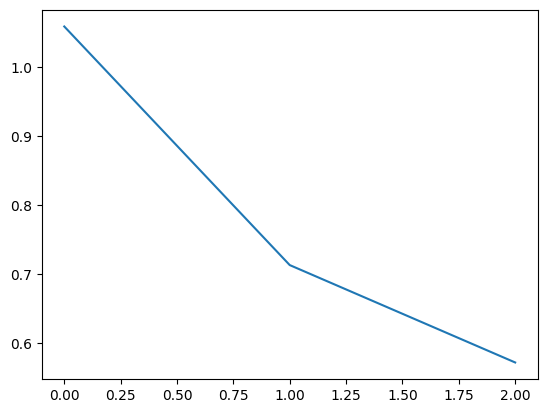

In [34]:
import matplotlib.pyplot as plt
plt.plot(loss)

In [35]:
import numpy as np

def get_f1_macro(y_true, y_pred_logits):
    """
    y_true: 1D array of actual class labels (e.g., [0, 1, 2])
    y_pred_logits: 2D array from model.predict() (probabilities or raw scores)
    """
    # 1. Convert logits/probabilities to class predictions
    # If y_pred_logits is already class labels, skip this step
    y_pred = np.argmax(y_pred_logits, axis=1)
    
    classes = np.unique(y_true)
    f1_scores = []
    
    for c in classes:
        # True Positives, False Positives, False Negatives
        tp = np.sum((y_pred == c) & (y_true == c))
        fp = np.sum((y_pred == c) & (y_true != c))
        fn = np.sum((y_pred != c) & (y_true == c))
        
        precision = tp / (tp + fp) if (tp + fp) > 0 else 0
        recall = tp / (tp + fn) if (tp + fn) > 0 else 0
        
        if (precision + recall) > 0:
            f1 = 2 * (precision * recall) / (precision + recall)
        else:
            f1 = 0
        f1_scores.append(f1)
    
    # Macro Average: Mean of all class F1 scores
    return np.mean(f1_scores)

In [36]:
for col in txs.columns:
  a = metric.loc[metric.label == col]
  txs[col] = (txs[col] - np.float64(a.iloc[:,1].to_numpy()))/np.float64(a.iloc[:,2].to_numpy())

/tmp/ipykernel_55/3568290101.py:3: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  txs[col] = (txs[col] - np.float64(a.iloc[:,1].to_numpy()))/np.float64(a.iloc[:,2].to_numpy())


In [39]:
# # After training
# batch_size = 64
# macro = []
# predictions = []
# for i in (0,txs.shape[0],batch_size):
#     predictions.append(model.predict(txs.iloc[i,np.min(i+batch_size,txs.shape[0])]))
get_f1_macro(target - 1,model.predict(txs.to_numpy()))

np.float64(0.7961939080125217)

In [40]:
testdf = pd.read_csv('/kaggle/input/nndataset/test_nn.csv')

In [44]:
testdf= testdf.iloc[:,1:]

In [45]:
testdf.describe()

,F_1,F_2,F_3,F_4,F_5,F_6,F_7,F_8,F_9,F_10,F_11,F_12,F_13,F_14,F_15,F_16,F_17,F_18,F_19,F_20
count,4000.000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.00000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000
mean,4.019,7.009000,5.124250,5.354000,3.504250,6.897500,7.524750,4.602750,5.172750,8.260500,6.472500,7.927250,3.04875,8.356250,3.695000,7.796000,16.090145,6.465937,4.696030,49.050750
std,1.919,3.308724,2.007566,2.242084,2.192415,2.007362,2.323411,2.655693,2.338006,2.476827,2.650849,2.070877,2.33436,1.560431,2.571309,1.619889,6.303756,2.922508,2.216845,27.081066
min,0.000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.00000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.900000
25%,3.000,5.000000,4.000000,4.000000,2.000000,6.000000,6.000000,3.000000,4.000000,7.000000,5.000000,7.000000,2.00000,8.000000,2.000000,7.000000,12.560000,5.000000,3.350000,32.100000
50%,4.000,7.000000,5.000000,6.000000,3.000000,7.000000,7.000000,4.000000,5.000000,8.000000,6.000000,8.000000,3.00000,8.000000,3.000000,8.000000,15.700000,6.250000,4.690000,43.500000
75%,5.000,9.000000,6.000000,7.000000,5.000000,8.000000,9.000000,6.000000,7.000000,10.000000,8.000000,9.000000,4.00000,9.000000,5.000000,9.000000,18.840000,8.750000,6.030000,63.300000
max,13.000,15.000000,13.000000,15.000000,15.000000,14.000000,15.000000,15.000000,15.000000,15.000000,15.000000,15.000000,15.00000,15.000000,15.000000,14.000000,40.820000,18.750000,10.050000,156.300000


In [46]:
for col in testdf.columns:
  a = metric.loc[metric.label == col]
  testdf[col] = (testdf[col] - np.float64(a.iloc[:,1].to_numpy()))/np.float64(a.iloc[:,2].to_numpy())

/tmp/ipykernel_55/4199571673.py:3: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  testdf[col] = (testdf[col] - np.float64(a.iloc[:,1].to_numpy()))/np.float64(a.iloc[:,2].to_numpy())


In [47]:
pred = model.predict(testdf.to_numpy())

In [48]:
sdf = pd.DataFrame({'id' : testdf.iloc[:,0], 'pred' : np.argmax(pred,axis = 1) + 1 })

In [49]:
sdf.to_csv('val_cls_nn.csv')